# Tournament Exploratory Data Analysis (EDA) & Schema Validator

This notebook provides a robust, memory-efficient framework to validate columns, aggregate match statistics, rank agents using Bradley-Terry Elo, and perform exploratory data analyses across all 9 Pokémon showdown generations.

### Scaling to 10k Games (~29 Million Battles / ~25GB Data)
Loading the entire 50-column dataset for 29 million games in a standard Pandas dataframe would require over 30GB of RAM and likely cause Out-of-Memory (OOM) crashes. 
To solve this, this notebook implements:
1. **Column Projection**: Loading only the minimal set of columns required for each specific visualization or calculation.
2. **Streaming Aggregation**: Processing files generator-style to compute matchup-level summaries before concatenating into memory.
3. **Optimized Pandas Types**: Minimizing memory footprint.

## 1. Imports and Configuration

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set aesthetic configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

# Define the root path of the tournament data
DATA_DIR = Path("../../data/benchmarks/all_10k")
if not DATA_DIR.exists():
    DATA_DIR = Path("/home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k")

print(f"Targeting data directory: {DATA_DIR.resolve()}")

Targeting data directory: /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k


## 2. Strict Schema Verification (100% Column Audit)

This check validates that **all 50 columns** are present in every matchup file, in the **exact same order**, without any extraneous or missing columns.

In [2]:
EXPECTED_COLUMNS = [
    "battle_id", "format", "heuristic", "opponent", "winner", "won", "turns",
    "decisions_us", "decisions_opp",
    "fallback_moves_us", "fallback_moves_opp",
    "error_moves_us", "error_moves_opp",
    "fainted_us", "remaining_pokemon_us", "total_hp_us",
    "fainted_opp", "remaining_pokemon_opp", "total_hp_opp",
    "team_us", "team_opp",
    "side_conditions_us", "side_conditions_opp",
    "voluntary_switches_us", "forced_switches_us",
    "voluntary_switches_opp", "forced_switches_opp",
    "move_stats_us", "move_stats_opp",
    "crit_us", "crit_opp",
    "miss_us", "miss_opp",
    "supereffective_us", "supereffective_opp",
    "hp_perc_us", "hp_perc_opp",
    "hazard_sets_us", "hazard_sets_opp",
    "hazard_removals_us", "hazard_removals_opp",
    "setup_uses_us", "setup_uses_opp",
    "ko_checks_us", "ko_checks_opp",
    "matchup_switches_us", "matchup_switches_opp",
    "terastallized_us", "terastallized_opp",
    "timestamp",
]
N_EXPECTED = len(EXPECTED_COLUMNS)

def run_schema_check(base_dir):
    csv_files = sorted([f for f in base_dir.glob("gen*/*.csv") 
                        if not f.name.startswith("_tmp") 
                        and "matchup_performance" not in f.name 
                        and "elo_summary" not in f.name])
    
    print(f"Found {len(csv_files)} CSV files across all generation directories.")
    
    issues = []
    checked_formats = set()
    
    for f_path in csv_files:
        checked_formats.add(f_path.parent.name)
        with open(f_path, newline="", encoding="utf-8") as f:
            reader = csv.reader(f)
            try:
                headers = next(reader)
            except StopIteration:
                issues.append(f"{f_path.relative_to(base_dir)}: File is empty.")
                continue
            
            if len(headers) != N_EXPECTED:
                issues.append(f"{f_path.relative_to(base_dir)}: Column count mismatch ({len(headers)} vs {N_EXPECTED})")
                continue
                
            # Check names and ordering
            for i, (expected, actual) in enumerate(zip(EXPECTED_COLUMNS, headers)):
                if expected != actual:
                    issues.append(f"{f_path.relative_to(base_dir)}: Out-of-order column at index {i} ('{actual}' instead of '{expected}')")
                    break
                    
    print(f"Validated folders: {sorted(list(checked_formats))}")
    if not issues:
        print("\n✅ ALL CHECKS PASSED: Every CSV file contains all 50 columns in the correct sequence.")
    else: 
        print(f"\n❌ SCHEMA CHECKS FAILED: Found {len(issues)} anomalies:")
        for issue in issues[:15]:
            print(f"  - {issue}")
        if len(issues) > 15:
            print(f"  ... and {len(issues) - 15} more.")

run_schema_check(DATA_DIR)

Found 2916 CSV files across all generation directories.
Validated folders: ['gen1randombattle', 'gen2randombattle', 'gen3randombattle', 'gen4randombattle', 'gen5randombattle', 'gen6randombattle', 'gen7randombattle', 'gen8randombattle', 'gen9randombattle']

✅ ALL CHECKS PASSED: Every CSV file contains all 50 columns in the correct sequence.


## 3. Streaming Matchup Aggregation (OOM-Safe)

This function reads each CSV file, loading only a projected subset of columns, groups them by matchup, and computes summaries. This keeps the memory footprint extremely light.

In [3]:
def aggregate_tournament_data(base_dir):
    csv_files = sorted([f for f in base_dir.glob("gen*/*.csv") 
                        if not f.name.startswith("_tmp") 
                        and "matchup_performance" not in f.name 
                        and "elo_summary" not in f.name])

    cols_to_load = [
        'format', 'heuristic', 'opponent', 'won', 'turns',
        'voluntary_switches_us', 'voluntary_switches_opp',
        'forced_switches_us', 'forced_switches_opp',
        'terastallized_us', 'terastallized_opp',
        'hazard_sets_us', 'hazard_sets_opp',
        'error_moves_us', 'error_moves_opp'
    ]
    
    chunks = []
    total_files = len(csv_files)
    
    print(f"Aggregating {total_files} files...")
    for idx, path in enumerate(csv_files):
        if (idx + 1) % 500 == 0:
            print(f"  Progress: {idx+1}/{total_files} files loaded...")
        df_f = pd.read_csv(path, usecols=cols_to_load)
        
        # Aggregation of the current file
        agg_f = df_f.groupby(['format', 'heuristic', 'opponent']).agg(
            games=('won', 'count'),
            wins=('won', 'sum'),
            turns_total=('turns', 'sum'),
            voluntary_switches_us_total=('voluntary_switches_us', 'sum'),
            voluntary_switches_opp_total=('voluntary_switches_opp', 'sum'),
            forced_switches_us_total=('forced_switches_us', 'sum'),
            forced_switches_opp_total=('forced_switches_opp', 'sum'),
            terastallized_us_total=('terastallized_us', 'sum'),
            terastallized_opp_total=('terastallized_opp', 'sum'),
            hazard_sets_us_total=('hazard_sets_us', 'sum'),
            hazard_sets_opp_total=('hazard_sets_opp', 'sum'),
            errors_us_total=('error_moves_us', 'sum'),
            errors_opp_total=('error_moves_opp', 'sum')
        ).reset_index()
        
        chunks.append(agg_f)

    # Combine all file summaries
    df_agg = pd.concat(chunks, ignore_index=True)
    # Final regroup to combine resume segments
    df_agg = df_agg.groupby(['format', 'heuristic', 'opponent']).sum().reset_index()
    
    # Derived statistics
    df_agg['win_rate'] = df_agg['wins'] / df_agg['games']
    df_agg['avg_turns'] = df_agg['turns_total'] / df_agg['games']
    df_agg['avg_vol_switches_us'] = df_agg['voluntary_switches_us_total'] / df_agg['games']
    df_agg['avg_vol_switches_opp'] = df_agg['voluntary_switches_opp_total'] / df_agg['games']
    
    print(f"Aggregation complete. Loaded stats for {df_agg['games'].sum():,} total games.")
    return df_agg

df_agg = aggregate_tournament_data(DATA_DIR)
df_agg.head(5)

Aggregating 2916 files...


  Progress: 500/2916 files loaded...
  Progress: 1000/2916 files loaded...
  Progress: 1500/2916 files loaded...
  Progress: 2000/2916 files loaded...
  Progress: 2500/2916 files loaded...
Aggregation complete. Loaded stats for 29,160,000 total games.


,format,heuristic,opponent,games,wins,turns_total,voluntary_switches_us_total,voluntary_switches_opp_total,forced_switches_us_total,forced_switches_opp_total,terastallized_us_total,terastallized_opp_total,hazard_sets_us_total,hazard_sets_opp_total,errors_us_total,errors_opp_total,win_rate,avg_turns,avg_vol_switches_us,avg_vol_switches_opp
0,gen1randombattle,abyssal,abyssal,10000,4865,185084,12446,12535,44883,44915,0,0,0,0,0,0,0.4865,18.5084,1.2446,1.2535
1,gen1randombattle,abyssal,max_power,10000,8001,187311,11358,10000,37525,48779,0,0,0,0,0,0,0.8001,18.7311,1.1358,1.0000
2,gen1randombattle,abyssal,one_step,10000,5874,178642,11155,10456,43442,46944,0,0,0,0,0,0,0.5874,17.8642,1.1155,1.0456
3,gen1randombattle,abyssal,random,10000,9903,230787,11815,95850,19901,49957,0,0,0,0,0,0,0.9903,23.0787,1.1815,9.5850
4,gen1randombattle,abyssal,safe_one_step,10000,5925,179035,11212,10500,43550,46971,0,0,0,0,0,0,0.5925,17.9035,1.1212,1.0500


## 4. Global Evolution Across Generations

In [4]:
# Aggregating per format
df_format = df_agg.groupby('format').agg(
    matchups=('wins', 'count'),
    total_games=('games', 'sum'),
    total_turns=('turns_total', 'sum'),
    total_vol_switches_us=('voluntary_switches_us_total', 'sum'),
    total_vol_switches_opp=('voluntary_switches_opp_total', 'sum'),
    total_forced_switches_us=('forced_switches_us_total', 'sum'),
    total_forced_switches_opp=('forced_switches_opp_total', 'sum'),
    total_errors_us=('errors_us_total', 'sum')
).reset_index()

df_format['avg_turns'] = df_format['total_turns'] / df_format['total_games']
df_format['avg_vol_switches_us'] = df_format['total_vol_switches_us'] / df_format['total_games']
df_format['avg_vol_switches_opp'] = df_format['total_vol_switches_opp'] / df_format['total_games']
df_format['avg_forced_switches_us'] = df_format['total_forced_switches_us'] / df_format['total_games']
df_format['avg_forced_switches_opp'] = df_format['total_forced_switches_opp'] / df_format['total_games']

df_format[['format', 'total_games', 'avg_turns', 'avg_vol_switches_us', 'avg_vol_switches_opp', 'avg_forced_switches_us', 'total_errors_us']]

,format,total_games,avg_turns,avg_vol_switches_us,avg_vol_switches_opp,avg_forced_switches_us,total_errors_us
0,gen1randombattle,3240000,18.777709,1.663896,1.656973,4.440618,0
1,gen2randombattle,3240000,28.775922,2.463762,2.521478,4.341635,0
2,gen3randombattle,3240000,22.553022,2.081560,2.106999,4.319286,0
3,gen4randombattle,3240000,19.009825,1.828813,1.932262,4.449739,0
4,gen5randombattle,3240000,19.060932,1.845312,1.971779,4.443302,0
5,gen6randombattle,3240000,19.445403,1.823199,1.960269,4.467355,0
6,gen7randombattle,3240000,19.716653,1.821106,1.949390,4.446917,0
7,gen8randombattle,3240000,18.492640,1.740901,1.817269,4.406176,0
8,gen9randombattle,3240000,18.266939,1.694728,1.798179,4.445313,0


/tmp/ipykernel_33426/1108446325.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_format, x='format', y='avg_turns', ax=axes[0], palette="Blues_d")


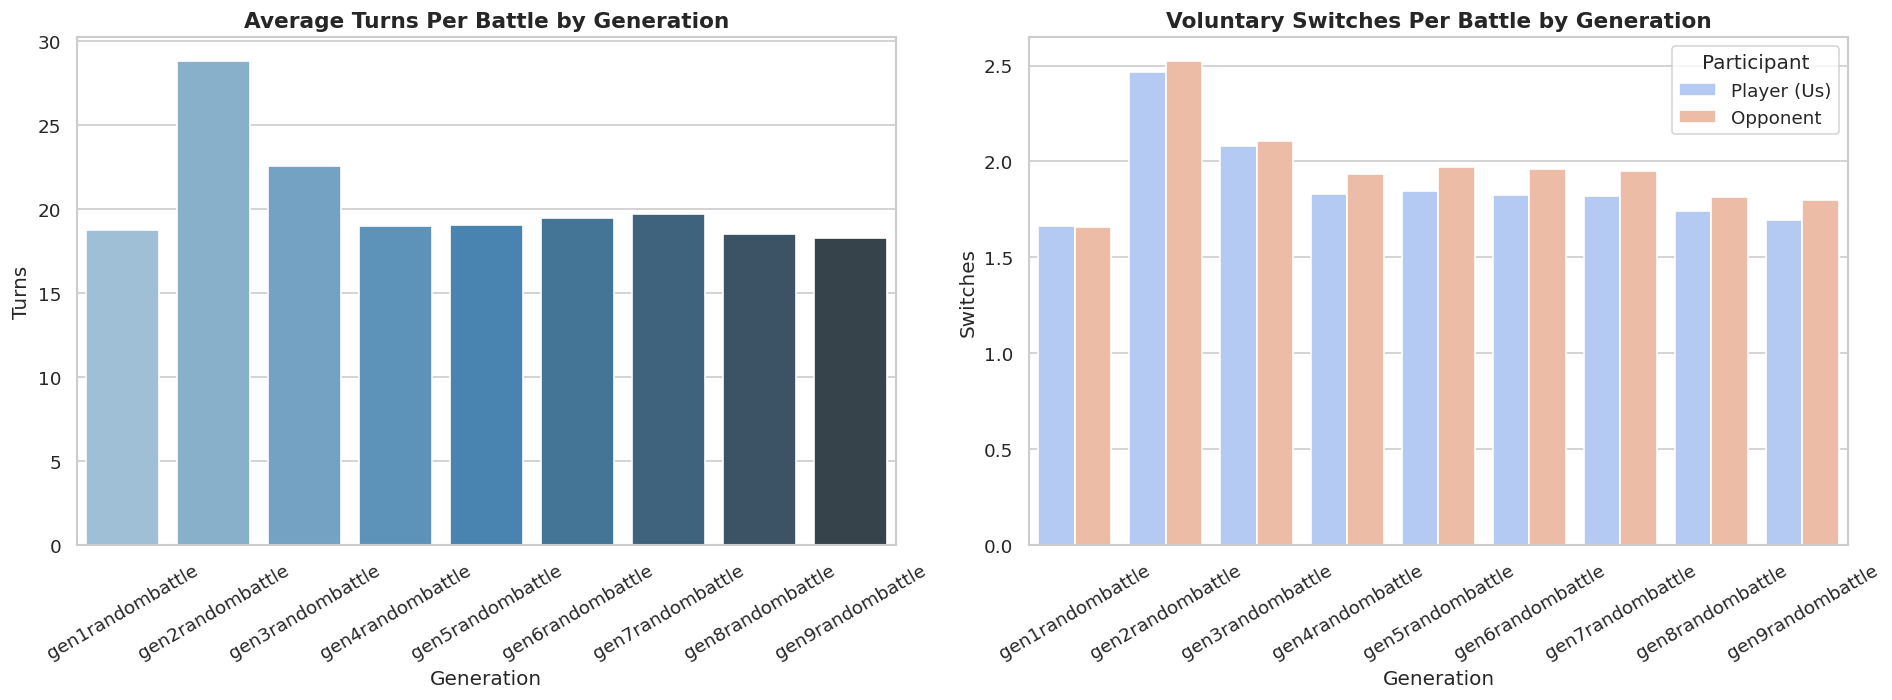

In [5]:
# Visualizing Game Lengths and Switches by Gen
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_format, x='format', y='avg_turns', ax=axes[0], palette="Blues_d")
axes[0].set_title("Average Turns Per Battle by Generation", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Turns")
axes[0].tick_params(axis='x', rotation=30)

df_sw_melt = pd.melt(
    df_format, 
    id_vars=['format'], 
    value_vars=['avg_vol_switches_us', 'avg_vol_switches_opp'],
    var_name='Player', 
    value_name='Switches'
)
df_sw_melt['Player'] = df_sw_melt['Player'].map({'avg_vol_switches_us': 'Player (Us)', 'avg_vol_switches_opp': 'Opponent'})

sns.barplot(data=df_sw_melt, x='format', y='Switches', hue='Player', ax=axes[1], palette="coolwarm")
axes[1].set_title("Voluntary Switches Per Battle by Generation", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Switches")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title="Participant")

plt.tight_layout()
plt.show()

## 5. Win Rate Heatmaps (Pairwise Matchups)

Plotting pairwise win rates per generation to visually assess agent counters and hierarchy.

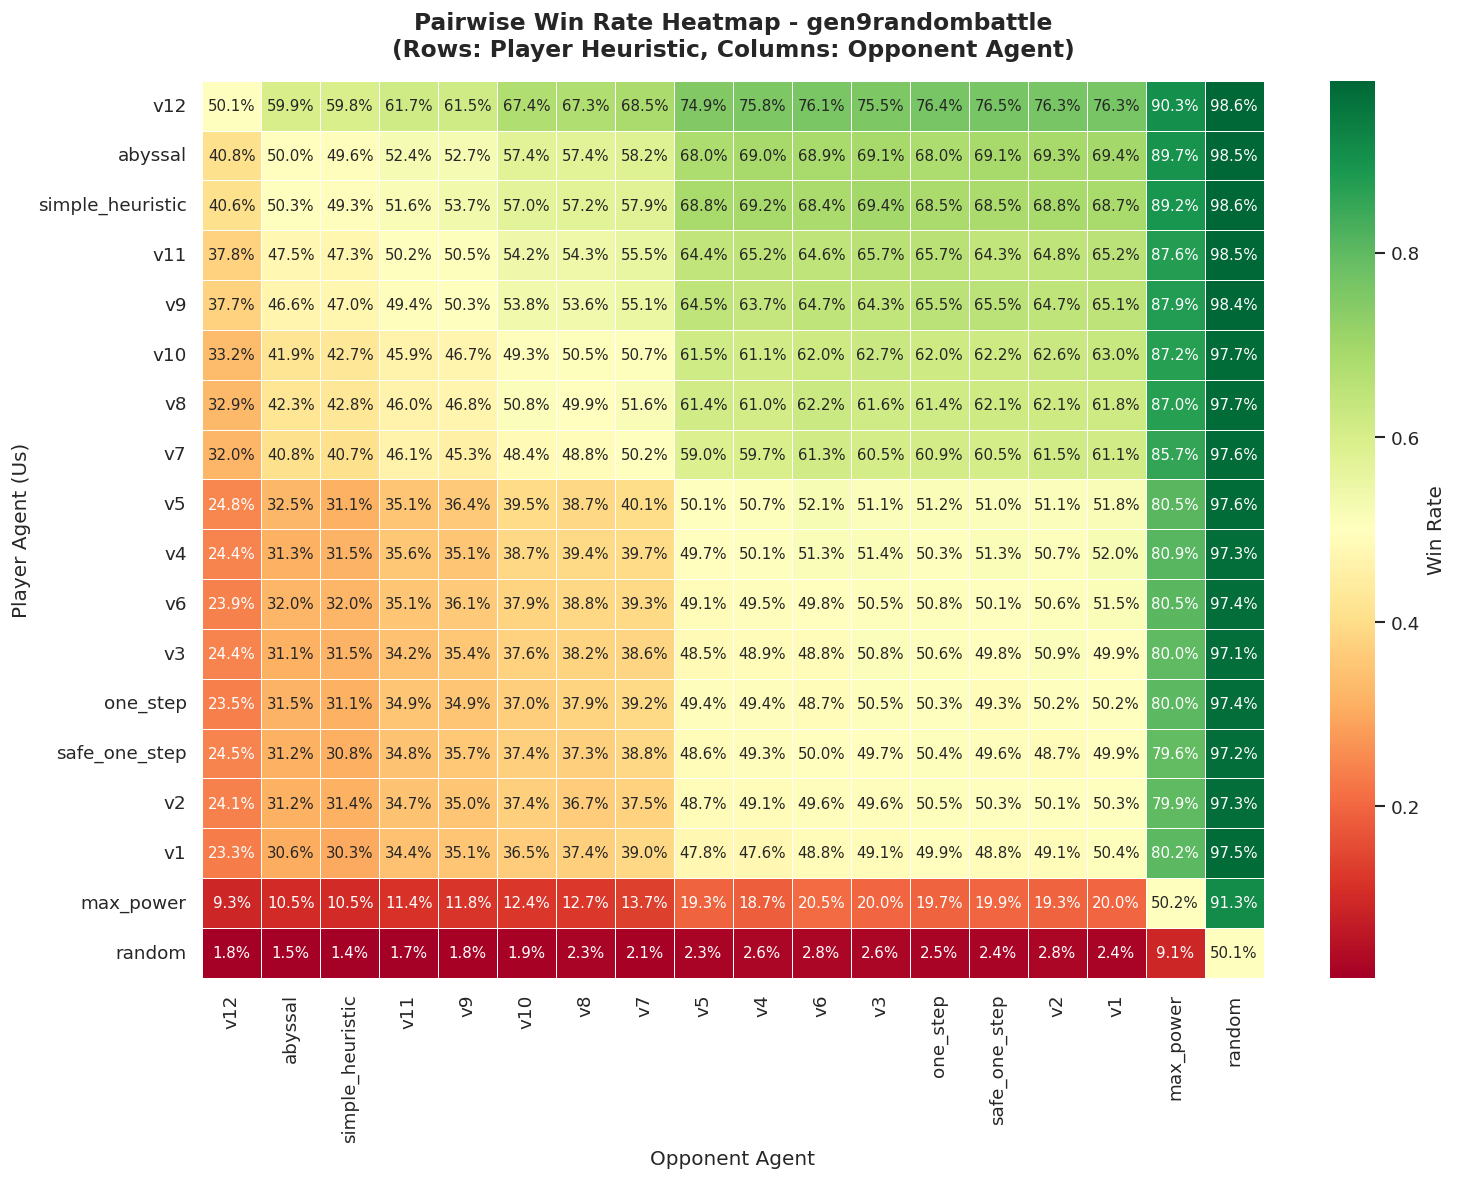

In [6]:
def display_heatmap(df_agg, format_name):
    df_f = df_agg[df_agg['format'] == format_name]
    if df_f.empty:
        print(f"No data available for {format_name}")
        return
        
    pivot = df_f.pivot(index='heuristic', columns='opponent', values='win_rate')
    
    # Sort both index and columns by average winrate descending
    rank = pivot.mean(axis=1).sort_values(ascending=False).index
    pivot = pivot.loc[rank, rank]
    
    plt.figure(figsize=(13, 10))
    sns.heatmap(
        pivot, 
        annot=True, 
        fmt=".1%", 
        cmap="RdYlGn", 
        cbar_kws={'label': 'Win Rate'}, 
        linewidths=0.5, 
        annot_kws={"size": 9}
    )
    plt.title(f"Pairwise Win Rate Heatmap - {format_name}\n(Rows: Player Heuristic, Columns: Opponent Agent)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Opponent Agent")
    plt.ylabel("Player Agent (Us)")
    plt.tight_layout()
    plt.show()

# Render Gen 9 heatmap
display_heatmap(df_agg, "gen9randombattle")

## 6. Bradley-Terry Elo Rating Analysis

The Bradley-Terry model computes mathematically optimized Elo ratings from wins/losses, anchoring `random` at 1000 Elo.

In [7]:
def calculate_bt_elo(df_format, anchor_agent="random", anchor_elo=1000, max_iter=300, tol=1e-6):
    agents = sorted(list(set(df_format['heuristic']).union(set(df_format['opponent']))))
    n_agents = len(agents)
    agent_to_idx = {name: i for i, name in enumerate(agents)}
    
    W = np.zeros((n_agents, n_agents))
    N = np.zeros((n_agents, n_agents))
    
    for _, row in df_format.iterrows():
        u = agent_to_idx[row['heuristic']]
        o = agent_to_idx[row['opponent']]
        W[u, o] += row['wins']
        N[u, o] += row['games']
        # Mirror opponent wins
        W[o, u] += (row['games'] - row['wins'])
        N[o, u] += row['games']
        
    # Solve iteratively
    pi = np.ones(n_agents)
    for _ in range(max_iter):
        pi_old = pi.copy()
        for i in range(n_agents):
            denom = 0.0
            for j in range(n_agents):
                if N[i, j] > 0:
                    denom += N[i, j] / (pi[i] + pi[j])
            if denom > 0:
                pi[i] = np.sum(W[i, :]) / denom
        pi /= np.mean(pi)
        if np.max(np.abs(pi - pi_old)) < tol:
            break
            
    elo = 400 * np.log10(pi)
    if anchor_agent in agent_to_idx:
        shift = anchor_elo - elo[agent_to_idx[anchor_agent]]
        elo += shift
        
    return pd.DataFrame({
        'Agent': agents,
        'Elo': elo,
        'Wins': np.sum(W, axis=1),
        'Games': np.sum(N, axis=1)
    }).sort_values(by='Elo', ascending=False).reset_index(drop=True)

# Compute Elo ratings for a subset of formats
for fmt in ["gen1randombattle", "gen5randombattle", "gen9randombattle"]:
    df_fmt = df_agg[df_agg['format'] == fmt]
    if not df_fmt.empty:
        print(f"\n--- Bradley-Terry Elo Rankings: {fmt} ---")
        print(calculate_bt_elo(df_fmt).to_markdown(index=False))


--- Bradley-Terry Elo Rankings: gen1randombattle ---
| Agent            |     Elo |   Wins |   Games |
|:-----------------|--------:|-------:|--------:|
| v12              | 1845.58 | 216579 |  360000 |
| simple_heuristic | 1841.07 | 214466 |  360000 |
| abyssal          | 1840.6  | 214246 |  360000 |
| v7               | 1824.1  | 206455 |  360000 |
| v10              | 1822.67 | 205774 |  360000 |
| v11              | 1821.75 | 205337 |  360000 |
| v8               | 1820.83 | 204899 |  360000 |
| v9               | 1809.2  | 199359 |  360000 |
| v5               | 1781.79 | 186255 |  360000 |
| v4               | 1781.08 | 185917 |  360000 |
| v3               | 1776.11 | 183540 |  360000 |
| v2               | 1775.8  | 183394 |  360000 |
| v6               | 1775.04 | 183029 |  360000 |
| one_step         | 1769.49 | 180381 |  360000 |
| safe_one_step    | 1768.88 | 180090 |  360000 |
| v1               | 1762.25 | 176934 |  360000 |
| max_power        | 1579.03 |  99465 |  36000

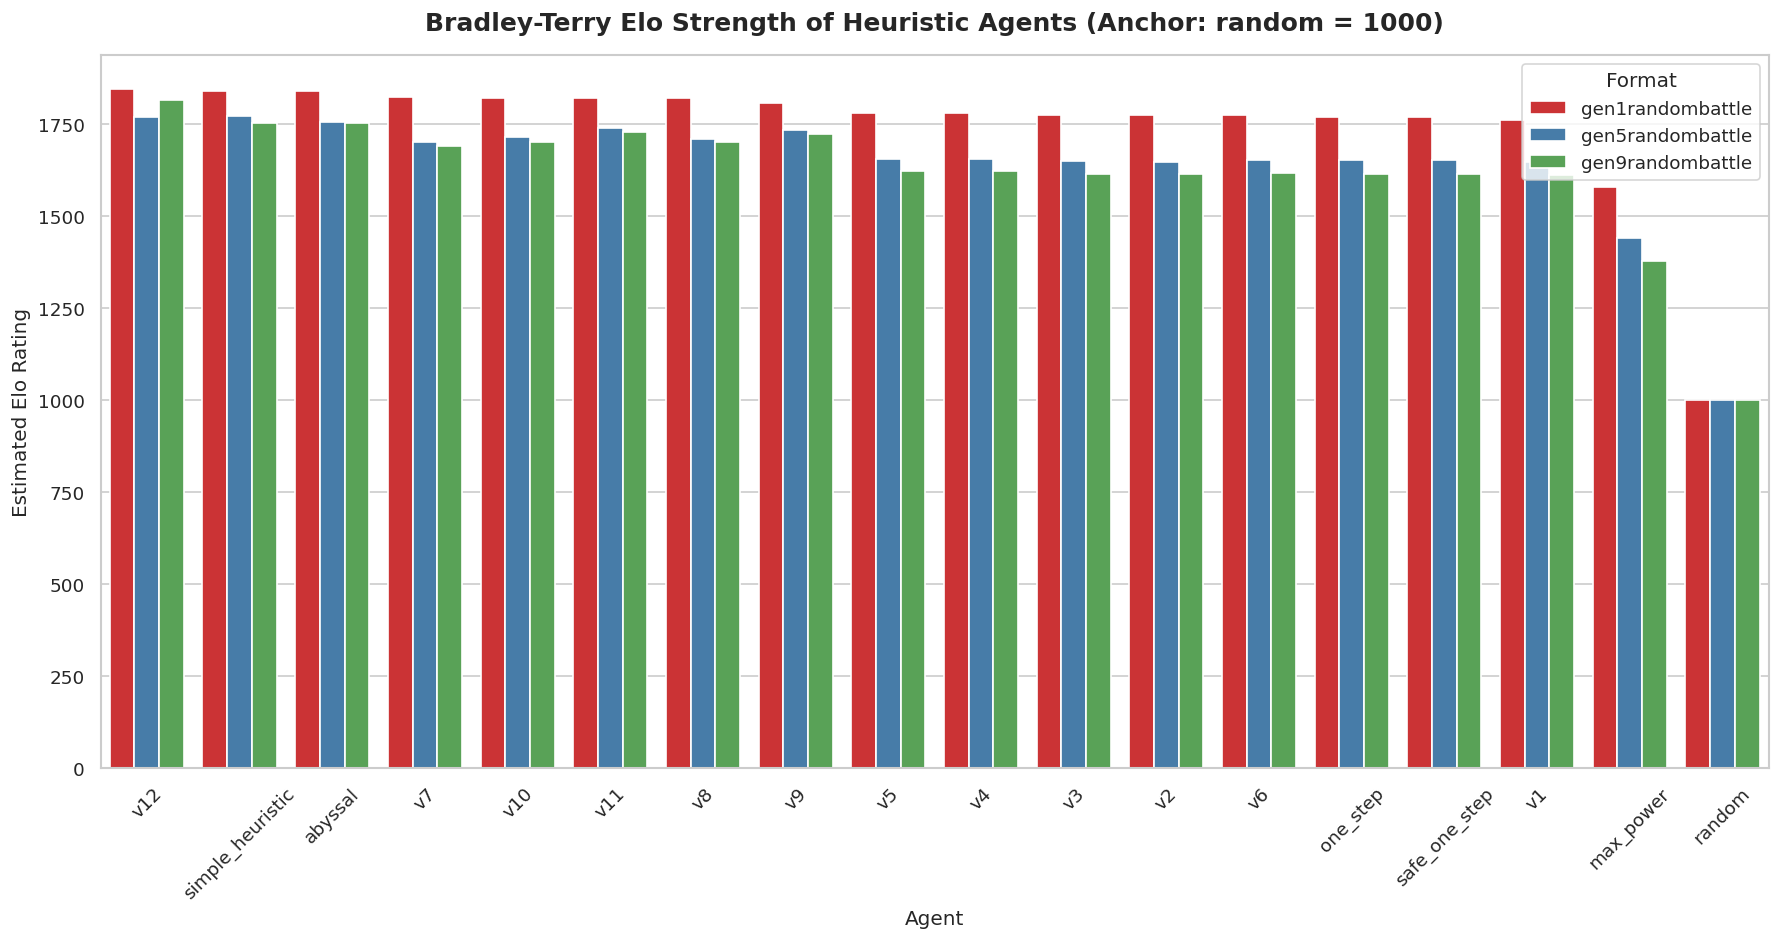

In [8]:
# Plotting Elo comparison for primary formats
primary_formats = ["gen1randombattle", "gen5randombattle", "gen9randombattle"]
elo_dfs = []

for fmt in primary_formats:
    df_fmt = df_agg[df_agg['format'] == fmt]
    if not df_fmt.empty:
        df_e = calculate_bt_elo(df_fmt)
        df_e['Format'] = fmt
        elo_dfs.append(df_e)

if elo_dfs:
    df_elo_all = pd.concat(elo_dfs, ignore_index=True)
    
    plt.figure(figsize=(15, 8))
    sns.barplot(data=df_elo_all, x='Agent', y='Elo', hue='Format', palette="Set1")
    plt.title("Bradley-Terry Elo Strength of Heuristic Agents (Anchor: random = 1000)", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Agent")
    plt.ylabel("Estimated Elo Rating")
    plt.xticks(rotation=45)
    plt.legend(title="Format")
    plt.tight_layout()
    plt.show()

## 7. Terastallization Efficacy & Behavior (Gen 9 Only)

Let's trace which heuristic agents Terastallize the most, and how Terastallization rate correlates with average Elo.

| heuristic        |   games |   tera_rate |     Elo |
|:-----------------|--------:|------------:|--------:|
| random           |  180000 |  0.999489   | 1000    |
| v12              |  180000 |  0.95285    | 1817    |
| safe_one_step    |  180000 |  0.00567222 | 1616.17 |
| one_step         |  180000 |  0.00552778 | 1615.79 |
| v10              |  180000 |  0.0015     | 1701.94 |
| v8               |  180000 |  0.00145    | 1700.8  |
| v11              |  180000 |  0.00127222 | 1728.39 |
| v9               |  180000 |  0.00125556 | 1724.99 |
| max_power        |  180000 |  0          | 1377.55 |
| abyssal          |  180000 |  0          | 1752.37 |
| v1               |  180000 |  0          | 1612.72 |
| simple_heuristic |  180000 |  0          | 1752.45 |
| v2               |  180000 |  0          | 1615.55 |
| v3               |  180000 |  0          | 1616.11 |
| v5               |  180000 |  0          | 1624.24 |
| v4               |  180000 |  0          | 1622.22 |
| v7      

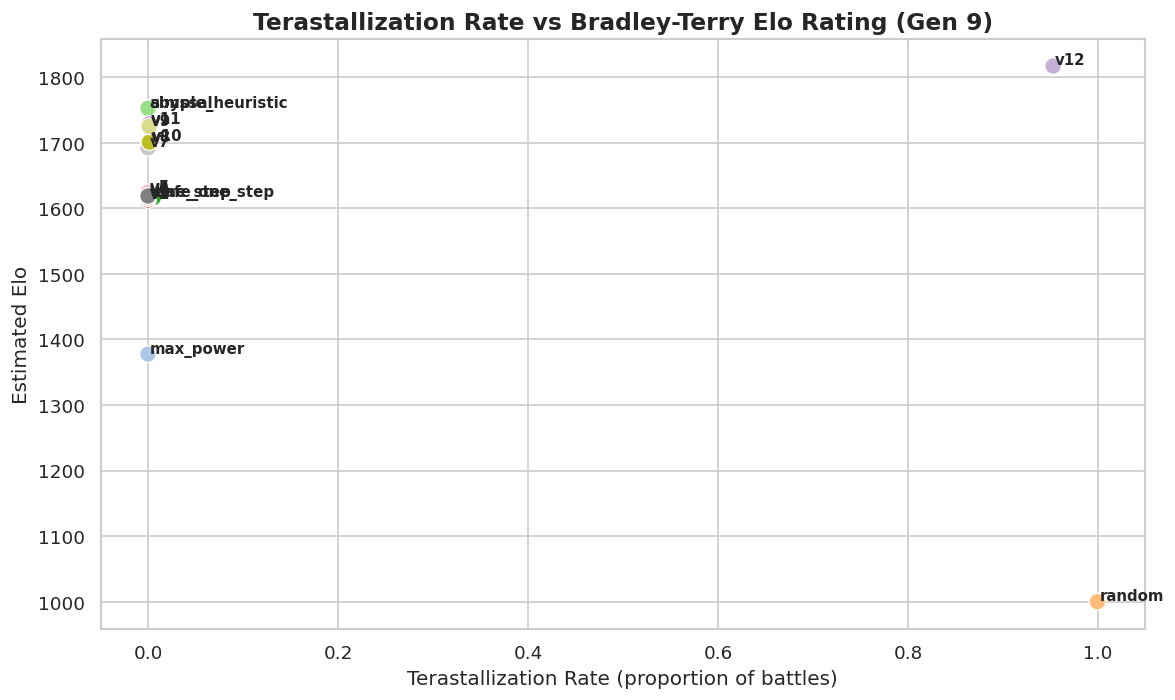

In [9]:
df_g9 = df_agg[df_agg['format'] == 'gen9randombattle'].copy()
if not df_g9.empty:
    # Calculate tera rate per matchup row
    df_g9['tera_rate_us'] = df_g9['terastallized_us_total'] / df_g9['games']
    
    # Group by agent
    tera_aggs = df_g9.groupby('heuristic').agg(
        games=('games', 'sum'),
        total_tera_us=('terastallized_us_total', 'sum'),
        avg_winrate=('wins', 'sum')
    ).reset_index()
    tera_aggs['tera_rate'] = tera_aggs['total_tera_us'] / tera_aggs['games']
    tera_aggs['avg_winrate'] = tera_aggs['avg_winrate'] / tera_aggs['games']
    
    # Add Elo rating to the scatter plot info
    g9_elo = calculate_bt_elo(df_g9)
    tera_aggs = tera_aggs.merge(g9_elo, left_on='heuristic', right_on='Agent')
    
    print(tera_aggs[['heuristic', 'games', 'tera_rate', 'Elo']].sort_values(by='tera_rate', ascending=False).to_markdown(index=False))
    
    # Scatter Plot: Tera Rate vs Elo Rating
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=tera_aggs, x='tera_rate', y='Elo', size='games', sizes=(100, 300), hue='heuristic', palette='tab20', legend=False)
    
    for _, row in tera_aggs.iterrows():
        plt.text(row['tera_rate'] + 0.002, row['Elo'] + 2, row['heuristic'], fontsize=9, fontweight='semibold')
        
    plt.title("Terastallization Rate vs Bradley-Terry Elo Rating (Gen 9)", fontsize=14, fontweight='bold')
    plt.xlabel("Terastallization Rate (proportion of battles)")
    plt.ylabel("Estimated Elo")
    plt.tight_layout()
    plt.show()

## 8. Hazard Layout Statistics

Hazards were introduced in Gen 2. This checks average entry hazards laid down per battle.

Average hazards set per battle:
| format           |   hazards_per_battle_us |   hazards_per_battle_opp |
|:-----------------|------------------------:|-------------------------:|
| gen1randombattle |              0          |                0         |
| gen2randombattle |              0.00880617 |                0.0088716 |
| gen3randombattle |              0.0106506  |                0.0107491 |
| gen4randombattle |              0.0393963  |                0.0392654 |
| gen5randombattle |              0.0387704  |                0.0388781 |
| gen6randombattle |              0.0284262  |                0.0286361 |
| gen7randombattle |              0.0263994  |                0.0264627 |
| gen8randombattle |              0.0314935  |                0.031333  |
| gen9randombattle |              0.027487   |                0.0275327 |


/tmp/ipykernel_33426/3897587166.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hazards, x='format', y='hazards_per_battle_us', palette="Purples_d")


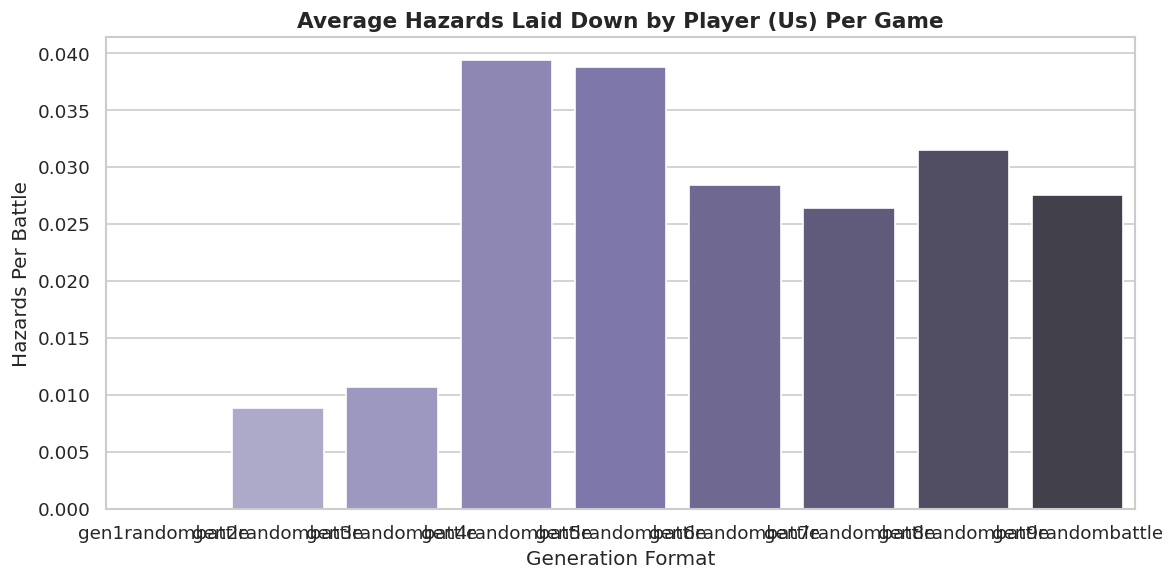

In [10]:
df_hazards = df_agg.groupby('format').agg(
    total_games=('games', 'sum'),
    hazards_us=('hazard_sets_us_total', 'sum'),
    hazards_opp=('hazard_sets_opp_total', 'sum')
).reset_index()

df_hazards['hazards_per_battle_us'] = df_hazards['hazards_us'] / df_hazards['total_games']
df_hazards['hazards_per_battle_opp'] = df_hazards['hazards_opp'] / df_hazards['total_games']

print("Average hazards set per battle:")
print(df_hazards[['format', 'hazards_per_battle_us', 'hazards_per_battle_opp']].to_markdown(index=False))

# Bar plot
plt.figure(figsize=(10, 5))
sns.barplot(data=df_hazards, x='format', y='hazards_per_battle_us', palette="Purples_d")
plt.title("Average Hazards Laid Down by Player (Us) Per Game", fontsize=13, fontweight='bold')
plt.xlabel("Generation Format")
plt.ylabel("Hazards Per Battle")
plt.tight_layout()
plt.show()

## 9. Comprehensive Column Ranges & Outlier Check (Min/Max/Avg)

To guarantee there are no data corruption issues (such as negative values, out-of-bounds counts, or NaN values), we calculate the , , and  for all numeric columns across a large sample of the raw dataset.

In [11]:
# Load a random sample of 50 matchup CSVs (~50,000 matches) to inspect raw row-level ranges
import random

all_files = list(DATA_DIR.glob("gen*/*.csv"))
all_files = [f for f in all_files if not f.name.startswith("_tmp") and "matchup_performance" not in f.name]

random.seed(42)
sample_files = random.sample(all_files, min(50, len(all_files)))
dfs = [pd.read_csv(f) for f in sample_files]
df_sample = pd.concat(dfs, ignore_index=True)

# Select numeric columns to inspect
numeric_cols = [
    "won", "turns", "decisions_us", "decisions_opp",
    "voluntary_switches_us", "voluntary_switches_opp",
    "forced_switches_us", "forced_switches_opp",
    "fainted_us", "fainted_opp",
    "remaining_pokemon_us", "remaining_pokemon_opp",
    "total_hp_us", "total_hp_opp",
    "crit_us", "crit_opp",
    "miss_us", "miss_opp",
    "supereffective_us", "supereffective_opp",
    "hazard_sets_us", "hazard_sets_opp",
    "hazard_removals_us", "hazard_removals_opp",
    "setup_uses_us", "setup_uses_opp",
    "ko_checks_us", "ko_checks_opp",
    "matchup_switches_us", "matchup_switches_opp",
    "terastallized_us", "terastallized_opp"
]

desc = df_sample[numeric_cols].describe().T[["min", "mean", "max"]]
desc.columns = ["Min Value", "Average Value", "Max Value"]
desc

,Min Value,Average Value,Max Value
won,0.0,0.450770,1.00
turns,6.0,19.425956,1000.00
decisions_us,0.0,13.581362,45854.00
decisions_opp,0.0,17.893402,27574.00
voluntary_switches_us,1.0,1.755126,160.00
voluntary_switches_opp,1.0,1.571724,301.00
forced_switches_us,0.0,4.553168,86.00
forced_switches_opp,0.0,4.257830,11.00
fainted_us,0.0,5.043066,6.00
fainted_opp,0.0,4.745274,6.00


## 9. Full Column Audit, Pokémon Popularity, and Move Usage Analysis

This section performs a deep descriptive statistics audit of the entire dataset and parses the complex string columns (`team_us`/`team_opp` and `move_stats_us`/`move_stats_opp`) to visualize the most common Pokémon and most frequently used moves in the tournament.

Found 2925 total files. Sampling 100 files for row-level details...

--- Descriptive Statistics Audit (Min/Mean/Max) ---


,Min Value,Average Value,Max Value
won,0.0,0.480616,1.00
turns,6.0,19.236785,1000.00
decisions_us,0.0,15.554541,45854.00
decisions_opp,0.0,17.786828,27574.00
voluntary_switches_us,1.0,1.507690,979.00
voluntary_switches_opp,1.0,1.518514,644.00
forced_switches_us,0.0,4.517228,132.00
forced_switches_opp,0.0,4.363867,13.00
fainted_us,0.0,4.981681,6.00
fainted_opp,0.0,4.879397,6.00


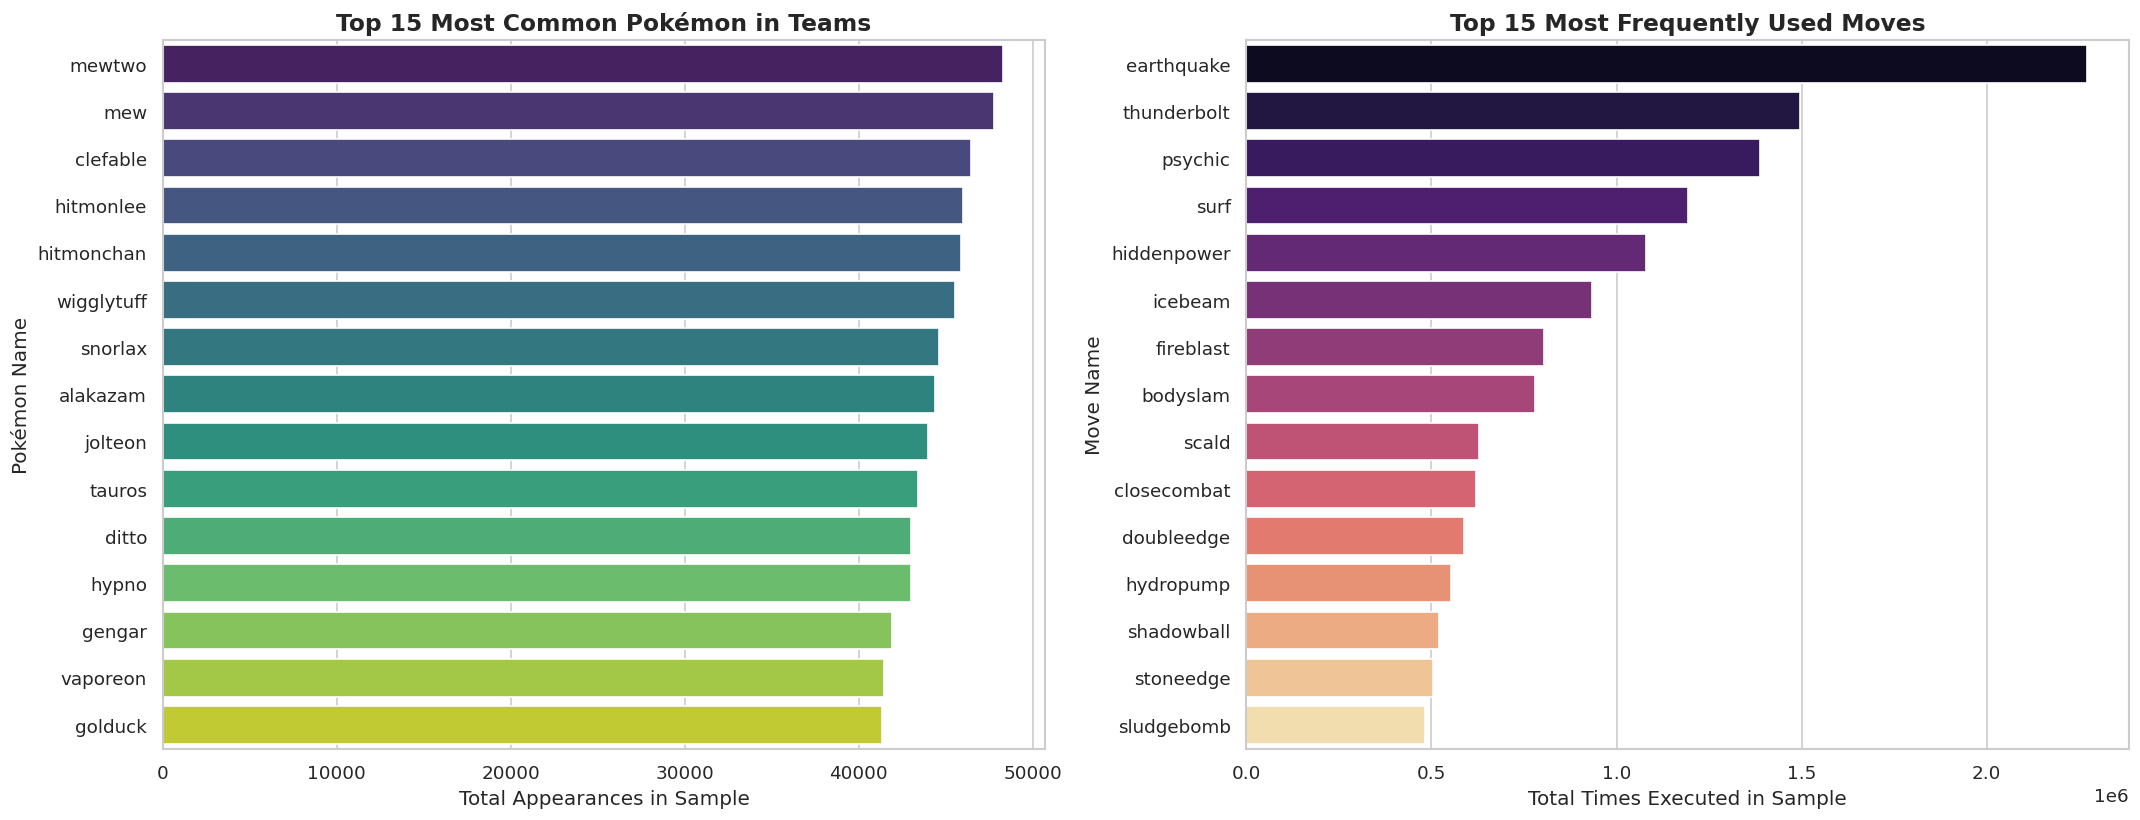

In [12]:
# 1. Descriptive Statistics on Numeric Columns
import random
from collections import Counter

all_files = list(DATA_DIR.glob('gen*/*.csv'))
all_files = [f for f in all_files if not f.name.startswith('_tmp') and 'matchup_performance' not in f.name]

print(f"Found {len(all_files)} total files. Sampling 100 files for row-level details...")
random.seed(42)
sample_files = random.sample(all_files, min(100, len(all_files)))
df_sample = pd.concat([pd.read_csv(f) for f in sample_files], ignore_index=True)

# Select numeric columns
numeric_cols = [
    'won', 'turns', 'decisions_us', 'decisions_opp',
    'voluntary_switches_us', 'voluntary_switches_opp',
    'forced_switches_us', 'forced_switches_opp',
    'fainted_us', 'fainted_opp',
    'remaining_pokemon_us', 'remaining_pokemon_opp',
    'total_hp_us', 'total_hp_opp',
    'crit_us', 'crit_opp',
    'miss_us', 'miss_opp',
    'supereffective_us', 'supereffective_opp',
    'hp_perc_us', 'hp_perc_opp',
    'hazard_sets_us', 'hazard_sets_opp',
    'hazard_removals_us', 'hazard_removals_opp',
    'setup_uses_us', 'setup_uses_opp',
    'ko_checks_us', 'ko_checks_opp',
    'matchup_switches_us', 'matchup_switches_opp',
    'terastallized_us', 'terastallized_opp'
]

print("\n--- Descriptive Statistics Audit (Min/Mean/Max) ---")
desc = df_sample[numeric_cols].describe().T[['min', 'mean', 'max']]
desc.columns = ['Min Value', 'Average Value', 'Max Value']
display(desc)

# 2. Parsing Pokémon Teams
pokemon_counter = Counter()
for col in ['team_us', 'team_opp']:
    if col in df_sample.columns:
        for val in df_sample[col].dropna():
            # Format: 'name(ability...)|name(ability...)'
            mons = str(val).split('|')
            for mon in mons:
                name = mon.split('(')[0].strip().lower()
                if name:
                    pokemon_counter[name] += 1

# 3. Parsing Move Usage
move_counter = Counter()
for col in ['move_stats_us', 'move_stats_opp']:
    if col in df_sample.columns:
        for val in df_sample[col].dropna():
            # Format: 'move:count|move:count'
            moves = str(val).split('|')
            for mv in moves:
                if ':' in mv:
                    name, count_str = mv.split(':', 1)
                    try:
                        move_counter[name.strip().lower()] += int(count_str)
                    except ValueError:
                        pass

# Plotting Popularity of Pokémon and Moves
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot Top 15 Pokémon
top_mons = pd.DataFrame(pokemon_counter.most_common(15), columns=['Pokemon', 'Appearances'])
sns.barplot(data=top_mons, x='Appearances', y='Pokemon', ax=axes[0], hue='Pokemon', legend=False, palette='viridis')
axes[0].set_title('Top 15 Most Common Pokémon in Teams', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Appearances in Sample')
axes[0].set_ylabel('Pokémon Name')

# Plot Top 15 Moves
top_moves = pd.DataFrame(move_counter.most_common(15), columns=['Move', 'Total Uses'])
sns.barplot(data=top_moves, x='Total Uses', y='Move', ax=axes[1], hue='Move', legend=False, palette='magma')
axes[1].set_title('Top 15 Most Frequently Used Moves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Times Executed in Sample')
axes[1].set_ylabel('Move Name')

plt.tight_layout()
plt.show()